🎯 FINAL PPG ANALYSIS

📅 Analysis Range (200Hz measurement time):
   Start: 2025-09-13 01:24:00
   End: 2025-09-13 09:07:00
   Duration: 7.7 hours

📂 Loading 25Hz: E0001_2.csv
   Shape: (144000, 10)


/tmp/ipython-input-1412875520.py:82: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_test = pd.to_datetime(df['datetime'], errors='coerce')


   🔧 Reconstructing from target_start: 2025-09-13 01:24:00
   ✅ Method: Reconstruction (40ms intervals)
   📅 Full range: 2025-09-13 01:24:00 ~ 2025-09-13 02:59:59.960000
   🎯 Target duration: 7.7 hours
   Matched in target range: 144,000 / 144,000 (100.0%)

📂 Loading 200Hz: ppgRaw2.csv
   📅 Range: 2025-09-13 01:24:00 ~ 2025-09-13 09:07:02.519108
   Samples: 5,599,248

📊 Samples in analysis range:
   25Hz: 144,000
   200Hz: 5,598,741

🔍 Found 1 measurement periods
   Scheduled periods: 1
   Period 0: 01:24:00 ~ 02:59:59 → 1 bursts
   Total: 1 periods with bursts

📊 Analyzing windows...
💾 Saved 190 windows

📊 RESULTS

Coverage: 25Hz=1.00 | 200Hz=1.00
SNR: 25Hz=-3.25±0.00 | 200Hz=2.26±3.91
Quality: 25Hz=190/190 | 200Hz=190/190 | Both=190/190

HR (n=190): Δ=-4.94±5.65 | MAE=5.83


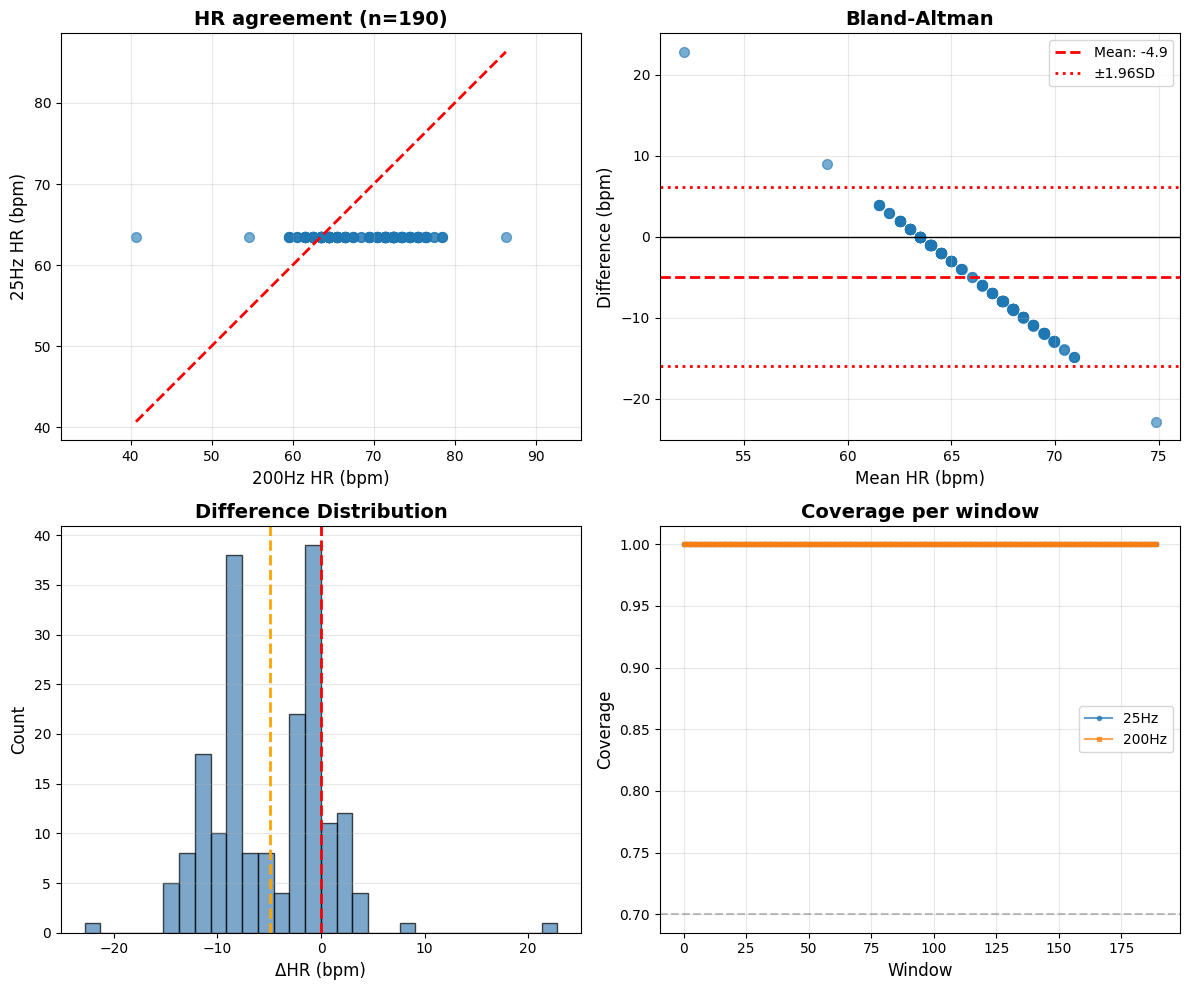


✅ Figure saved: /content/drive/MyDrive/Colab Notebooks/results_sched_full/final_analysis_analysis.png

✅ Complete!


In [62]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FINAL: 200Hz time = analysis range, 25Hz auto-find matching
# ============================================================

CFG = {
    # ============================================================
    # FILES
    # ============================================================
    "FILE_25": "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_2.csv", #수정해야할 사항 >>>>>>>>>>>>>>>>>>>>> : 파일명
    "FILE_200": "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw2.csv", #수정해야할 사항 >>>>>>>>>>>>>>>>>>>>> : 파일명

    # ============================================================
    # ✅ ANALYSIS RANGE (200Hz 측정 시간)
    # ============================================================
    "NIGHT_START": "2025-09-13 01:24:00",  # 수정해야할 사항 >>>>>>>>>>>>>>>>>>>>> : 200Hz 시작
    "NIGHT_END": "2025-09-13 09:07:00",    # 수정해야할 사항 >>>>>>>>>>>>>>>>>>>>> :200Hz 종료

    # ============================================================
    # SETTINGS
    # ============================================================
    "PPG_COL_25": "ppg",

    "READ200_HEADER_NONE": True,
    "T_COL_200": 0,
    "PPG_COL_200": 1,
    "T_UNIT_200": "us",

    "FS_25": 25,
    "FS_200": 200,

    # SCHEDULE
    "SCHED": [
        {"start_min": 20, "end_min": 30},
        {"start_min": 50, "end_min": 60},
    ],

    # ANALYSIS PARAMS
    "MAX_GAP_LONG_SEC": 60,
    "MIN_SEGMENT_SEC": 60,
    "BURST_GAP_SEC": 15,
    "MIN_BURST_SEC": 8,
    "WIN_SEC": 60,
    "STEP_SEC": 30,

    # QC
    "MIN_VALID_RATIO_25": 0.70,
    "MIN_COV_EXPECT_200": 0.90,
    "MIN_SNR_DB": -10.0,

    # OUTPUT
    "OUT_DIR": "/content/drive/MyDrive/Colab Notebooks/results_sched_full",
    "RUN_ID": "final_analysis",
}

os.makedirs(CFG["OUT_DIR"], exist_ok=True)

# ============================================================
# Smart 25Hz Loader - Auto-find matching time range
# ============================================================

def load_25hz_auto_match(filepath, ppg_col, target_start, target_end):
    """
    Load 25Hz and automatically find data matching target time range
    Handles both formats and date rollover
    """
    df = pd.read_csv(filepath)

    print(f"📂 Loading 25Hz: {os.path.basename(filepath)}")
    print(f"   Shape: {df.shape}")

    dt = None

    # ============================================================
    # TRY 1: 'datetime' column with full timestamp
    # ============================================================
    if 'datetime' in df.columns:
        dt_test = pd.to_datetime(df['datetime'], errors='coerce')
        valid_ratio = dt_test.notna().mean()

        if valid_ratio > 0.5:
            valid_dates = dt_test.dropna()
            if len(valid_dates) > 0 and 2000 <= valid_dates.iloc[0].year <= 2030:
                dt = dt_test
                print(f"   ✅ Method: 'datetime' column")

    # ============================================================
    # TRY 2: 'timestamp' with diversity
    # ============================================================
    if dt is None and 'timestamp' in df.columns:
        t_ms = pd.to_numeric(df['timestamp'], errors='coerce')

        if t_ms.notna().mean() > 0.9:
            unique_ratio = t_ms.nunique() / len(t_ms)

            if unique_ratio > 0.1:
                dt = pd.to_datetime(t_ms, unit='ms', errors='coerce')
                print(f"   ✅ Method: 'timestamp' (epoch ms)")

    # ============================================================
    # TRY 3: Reconstruct from target_start
    # ============================================================
    if dt is None:
        print(f"   🔧 Reconstructing from target_start: {target_start}")

        dt_base = pd.to_datetime(target_start)
        intervals_ms = np.arange(len(df)) * 40  # 40ms per sample
        dt = pd.Series(dt_base + pd.to_timedelta(intervals_ms, unit='ms'))

        print(f"   ✅ Method: Reconstruction (40ms intervals)")

    # ============================================================
    # Ensure dt is Series
    # ============================================================
    if not isinstance(dt, pd.Series):
        dt = pd.Series(dt).reset_index(drop=True)

    # Extract PPG
    ppg = pd.to_numeric(df[ppg_col], errors='coerce')
    if not isinstance(ppg, pd.Series):
        ppg = pd.Series(ppg).reset_index(drop=True)

    print(f"   📅 Full range: {dt.min()} ~ {dt.max()}")

    # ============================================================
    # Find matching segment
    # ============================================================
    target_start_dt = pd.to_datetime(target_start)
    target_end_dt = pd.to_datetime(target_end)

    duration_hours = (target_end_dt - target_start_dt).total_seconds() / 3600
    print(f"   🎯 Target duration: {duration_hours:.1f} hours")

    # Find data that overlaps with target range
    mask = (dt >= target_start_dt) & (dt <= target_end_dt)
    n_matched = mask.sum()

    print(f"   Matched in target range: {n_matched:,} / {len(df):,} ({n_matched/len(df):.1%})")

    if n_matched == 0:
        print(f"   ⚠️ No overlap! Auto-adjusting...")

        dt_min = dt.min()
        dt_max = dt.max()
        data_duration_hours = (dt_max - dt_min).total_seconds() / 3600

        print(f"   25Hz data duration: {data_duration_hours:.1f} hours")
        print(f"   25Hz range: {dt_min} ~ {dt_max}")
        print(f"   Target range: {target_start_dt} ~ {target_end_dt}")

        # Calculate offset
        if dt_max < target_start_dt:
            # 25Hz data is too early
            offset = target_start_dt - dt_min
            dt = dt + offset
            print(f"   ✅ Shifted forward: +{offset.total_seconds()/3600:.1f} hours")
        elif dt_min > target_end_dt:
            # 25Hz data is too late
            offset = dt_min - target_start_dt
            dt = dt - offset
            print(f"   ✅ Shifted backward: -{offset.total_seconds()/3600:.1f} hours")
        else:
            # Partial overlap - use as is
            print(f"   ✅ Partial overlap detected, using as is")

        print(f"   Adjusted range: {dt.min()} ~ {dt.max()}")

    return dt, ppg


def load_200hz_data(filepath, t_col, ppg_col, t_unit, start_dt):
    """Load 200Hz data"""
    df = pd.read_csv(filepath, header=None)

    t = pd.to_numeric(df.iloc[:, t_col], errors='coerce').to_numpy()
    t_valid = t[np.isfinite(t)]
    t0 = t_valid[0]

    dt = pd.to_datetime(start_dt) + pd.to_timedelta((t - t0), unit=t_unit)
    ppg = pd.to_numeric(df.iloc[:, ppg_col], errors='coerce').to_numpy()

    return dt, ppg


# ============================================================
# Analysis Functions
# ============================================================

def find_measurement_periods(dt, x, max_gap_sec=60, min_duration_sec=60):
    """Find continuous measurement periods"""
    dt = pd.to_datetime(pd.Series(dt), errors='coerce')
    x = pd.to_numeric(pd.Series(x), errors='coerce')

    valid = dt.notna() & x.notna()
    dt = dt[valid].reset_index(drop=True)
    x = x[valid].reset_index(drop=True)

    if len(dt) == 0:
        return [], dt, x

    df = pd.DataFrame({'dt': dt, 'x': x})
    df = df.groupby('dt').mean().reset_index().sort_values('dt').reset_index(drop=True)
    dt = df['dt']
    x = df['x']

    intervals = dt.diff().dt.total_seconds()
    gap_mask = intervals > max_gap_sec

    period_starts = np.concatenate([[0], np.where(gap_mask)[0]])
    period_ends = np.concatenate([np.where(gap_mask)[0] - 1, [len(dt) - 1]])

    periods = []
    for start_idx, end_idx in zip(period_starts, period_ends):
        start_dt = dt.iloc[start_idx]
        end_dt = dt.iloc[end_idx]
        duration = (end_dt - start_dt).total_seconds()

        if duration >= min_duration_sec:
            periods.append({
                'start_idx': int(start_idx),
                'end_idx': int(end_idx),
                'start_dt': start_dt,
                'end_dt': end_dt,
                'duration_sec': float(duration),
                'n_samples': int(end_idx - start_idx + 1)
            })

    return periods, dt, x


def split_period_into_bursts(dt, x, period, burst_gap_sec=15, min_burst_sec=8):
    """Split period into bursts"""
    mask = (dt >= period['start_dt']) & (dt <= period['end_dt'])
    dt_period = dt[mask].reset_index(drop=True)
    x_period = x[mask].reset_index(drop=True)

    if len(dt_period) == 0:
        return []

    intervals = dt_period.diff().dt.total_seconds()
    gap_mask = intervals > burst_gap_sec

    burst_starts = np.concatenate([[0], np.where(gap_mask)[0]])
    burst_ends = np.concatenate([np.where(gap_mask)[0] - 1, [len(dt_period) - 1]])

    bursts = []
    for start_idx, end_idx in zip(burst_starts, burst_ends):
        start_dt = dt_period.iloc[start_idx]
        end_dt = dt_period.iloc[end_idx]
        duration = (end_dt - start_dt).total_seconds()

        if duration >= min_burst_sec:
            bursts.append({
                'start_dt': start_dt,
                'end_dt': end_dt,
                'duration_sec': float(duration),
                'n_samples': int(end_idx - start_idx + 1)
            })

    return bursts


def extract_burst_data(dt, x, burst):
    """Extract burst data"""
    mask = (dt >= burst['start_dt']) & (dt <= burst['end_dt'])
    x_burst = x[mask] if hasattr(x, '__getitem__') else x.loc[mask]
    return np.asarray(x_burst, dtype=float)


def concatenate_bursts(dt, x, bursts):
    """Concatenate bursts"""
    segments = []
    for burst in bursts:
        data = extract_burst_data(dt, x, burst)
        if len(data) > 0:
            segments.append(data)
    return np.concatenate(segments) if segments else np.array([])


def resample_uniform_simple(dt, x, fs, win_start, win_end):
    """Simple resampling"""
    dt = pd.to_datetime(pd.Series(dt), errors='coerce')
    x = pd.to_numeric(pd.Series(x), errors='coerce')

    m = (dt >= win_start) & (dt < win_end) & dt.notna() & x.notna()
    return np.asarray(x[m], dtype=float)


def band_snr_simple(x, fs, f_lo=0.7, f_hi=3.0):
    """SNR calculation"""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < int(fs * 5):
        return np.nan

    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = np.abs(X) ** 2
    f = np.fft.rfftfreq(n, d=1/fs)

    band = (f >= f_lo) & (f <= f_hi)
    out = ((f >= 0.1) & (f < f_lo)) | ((f > f_hi) & (f <= 8.0))

    pb = P[band].sum()
    po = P[out].sum()
    return 10.0 * np.log10((pb + 1e-12) / (po + 1e-12)) if po > 0 else np.nan


def hr_from_fft(x, fs, bpm_lo=40, bpm_hi=180):
    """HR estimation"""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) < int(fs * 10):
        return np.nan

    x = x - np.nanmean(x)
    n = len(x)
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    P = np.abs(X) ** 2
    f = np.fft.rfftfreq(n, d=1/fs)

    f_lo = bpm_lo / 60.0
    f_hi = bpm_hi / 60.0
    m = (f >= f_lo) & (f <= f_hi)

    if m.sum() < 3:
        return np.nan

    return float(f[m][np.argmax(P[m])] * 60.0)


def rolling_windows(t0, t1, win_sec, step_sec):
    """Generate windows"""
    current = pd.to_datetime(t0)
    end = pd.to_datetime(t1)
    win = pd.Timedelta(seconds=win_sec)
    step = pd.Timedelta(seconds=step_sec)

    while current + win <= end:
        yield current, current + win
        current = current + step


def cov_expected_clamped(n_samples, fs, win_sec):
    """Expected coverage"""
    exp = int(round(fs * win_sec))
    return float(min(1.0, n_samples / exp)) if exp > 0 else 0.0


# ============================================================
# MAIN ANALYSIS
# ============================================================

print("="*70)
print("🎯 FINAL PPG ANALYSIS")
print("="*70)

# Analysis range
t0 = pd.to_datetime(CFG["NIGHT_START"])
t1 = pd.to_datetime(CFG["NIGHT_END"])

print(f"\n📅 Analysis Range (200Hz measurement time):")
print(f"   Start: {t0}")
print(f"   End: {t1}")
print(f"   Duration: {(t1-t0).total_seconds()/3600:.1f} hours")

# Load 25Hz - auto-match to target range
print(f"\n" + "="*70)
dt25, x25 = load_25hz_auto_match(
    CFG["FILE_25"],
    CFG["PPG_COL_25"],
    CFG["NIGHT_START"],
    CFG["NIGHT_END"]
)

# Load 200Hz
print(f"\n" + "="*70)
print(f"📂 Loading 200Hz: {os.path.basename(CFG['FILE_200'])}")
dt200, x200 = load_200hz_data(
    CFG["FILE_200"],
    CFG["T_COL_200"],
    CFG["PPG_COL_200"],
    CFG["T_UNIT_200"],
    CFG["NIGHT_START"]
)
print(f"   📅 Range: {dt200.min()} ~ {dt200.max()}")
print(f"   Samples: {len(dt200):,}")

# Cut to analysis range
mask_25 = (dt25 >= t0) & (dt25 <= t1)
mask_200 = (dt200 >= t0) & (dt200 <= t1)

# Convert to Series and reset index
dt25 = pd.Series(dt25[mask_25].values).reset_index(drop=True)
x25 = pd.Series(x25[mask_25].values).reset_index(drop=True)
dt200 = dt200[mask_200]
x200 = x200[mask_200]

print(f"\n📊 Samples in analysis range:")
print(f"   25Hz: {len(dt25):,}")
print(f"   200Hz: {len(dt200):,}")

if len(dt25) == 0 or len(dt200) == 0:
    print("\n❌ No data in analysis range!")
    raise SystemExit

# Find periods
print(f"\n" + "="*70)
periods_25, dt25_clean, x25_clean = find_measurement_periods(
    dt25, x25,
    max_gap_sec=CFG["MAX_GAP_LONG_SEC"],
    min_duration_sec=CFG["MIN_SEGMENT_SEC"]
)

print(f"🔍 Found {len(periods_25)} measurement periods")

# Filter by schedule
scheduled_periods = []
for period in periods_25:
    minute = period['start_dt'].minute
    for rule in CFG["SCHED"]:
        if rule["start_min"] <= minute < rule["end_min"]:
            scheduled_periods.append(period)
            break

print(f"   Scheduled periods: {len(scheduled_periods)}")

# Split into bursts
all_period_bursts = []
for i, period in enumerate(scheduled_periods):
    bursts = split_period_into_bursts(
        dt25_clean, x25_clean, period,
        burst_gap_sec=CFG["BURST_GAP_SEC"],
        min_burst_sec=CFG["MIN_BURST_SEC"]
    )

    if i < 3:
        print(f"   Period {i}: {period['start_dt'].strftime('%H:%M:%S')} ~ {period['end_dt'].strftime('%H:%M:%S')} → {len(bursts)} bursts")

    if len(bursts) > 0:
        all_period_bursts.append({'period': period, 'bursts': bursts})

print(f"   Total: {len(all_period_bursts)} periods with bursts")

# Analyze windows
print(f"\n" + "="*70)
print(f"📊 Analyzing windows...")

rows = []
window_id = 0

for period_data in all_period_bursts:
    period = period_data['period']
    bursts = period_data['bursts']

    for w0, w1 in rolling_windows(period['start_dt'], period['end_dt'], CFG["WIN_SEC"], CFG["STEP_SEC"]):
        bursts_in_win = [b for b in bursts if not (b['end_dt'] < w0 or b['start_dt'] > w1)]

        if len(bursts_in_win) == 0:
            continue

        sig25 = concatenate_bursts(dt25_clean, x25_clean, bursts_in_win)
        sig200 = resample_uniform_simple(dt200, x200, CFG["FS_200"], w0, w1)

        total_burst_dur = sum([b['duration_sec'] for b in bursts_in_win])
        cov25 = len(sig25) / (CFG["FS_25"] * total_burst_dur) if total_burst_dur > 0 else 0
        cov200 = cov_expected_clamped(len(sig200), CFG["FS_200"], CFG["WIN_SEC"])

        snr25 = band_snr_simple(sig25, CFG["FS_25"]) if len(sig25) else np.nan
        snr200 = band_snr_simple(sig200, CFG["FS_200"]) if len(sig200) else np.nan

        hr25 = hr_from_fft(sig25, CFG["FS_25"]) if len(sig25) >= CFG["FS_25"] * 10 else np.nan
        hr200 = hr_from_fft(sig200, CFG["FS_200"]) if len(sig200) >= CFG["FS_200"] * 10 else np.nan

        d_hr = float(hr25 - hr200) if np.isfinite(hr25) and np.isfinite(hr200) else np.nan

        ok25 = int((cov25 >= CFG["MIN_VALID_RATIO_25"]) and np.isfinite(snr25) and (snr25 >= CFG["MIN_SNR_DB"]))
        ok200 = int((cov200 >= CFG["MIN_COV_EXPECT_200"]) and np.isfinite(snr200) and (snr200 >= CFG["MIN_SNR_DB"]))

        rows.append({
            "run_id": CFG["RUN_ID"],
            "window_id": window_id,
            "w0": w0,
            "w1": w1,
            "n_bursts": len(bursts_in_win),
            "cov25": cov25,
            "cov200": cov200,
            "n25": len(sig25),
            "n200": len(sig200),
            "snr25_db": snr25,
            "snr200_db": snr200,
            "hr25_bpm": hr25,
            "hr200_bpm": hr200,
            "d_hr_25_minus_200": d_hr,
            "ok25": ok25,
            "ok200": ok200,
        })

        window_id += 1

# Save
out = pd.DataFrame(rows)
win_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_windows.csv")
out.to_csv(win_path, index=False)

print(f"💾 Saved {len(out)} windows")

# Summary & Plots
if len(out) > 0:
    print("\n" + "="*70)
    print("📊 RESULTS")
    print("="*70)

    print(f"\nCoverage: 25Hz={out['cov25'].mean():.2f} | 200Hz={out['cov200'].mean():.2f}")
    print(f"SNR: 25Hz={out['snr25_db'].mean():.2f}±{out['snr25_db'].std():.2f} | 200Hz={out['snr200_db'].mean():.2f}±{out['snr200_db'].std():.2f}")
    print(f"Quality: 25Hz={out['ok25'].sum()}/{len(out)} | 200Hz={out['ok200'].sum()}/{len(out)} | Both={((out['ok25']==1)&(out['ok200']==1)).sum()}/{len(out)}")

    valid_hr = out.dropna(subset=["d_hr_25_minus_200"])
    if len(valid_hr) > 0:
        print(f"\nHR (n={len(valid_hr)}): Δ={valid_hr['d_hr_25_minus_200'].mean():.2f}±{valid_hr['d_hr_25_minus_200'].std():.2f} | MAE={valid_hr['d_hr_25_minus_200'].abs().mean():.2f}")

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        # HR scatter
        axes[0, 0].scatter(valid_hr['hr200_bpm'], valid_hr['hr25_bpm'], alpha=0.6, s=50)
        lo = min(valid_hr['hr200_bpm'].min(), valid_hr['hr25_bpm'].min())
        hi = max(valid_hr['hr200_bpm'].max(), valid_hr['hr25_bpm'].max())
        axes[0, 0].plot([lo, hi], [lo, hi], 'r--', linewidth=2)
        axes[0, 0].set_xlabel('200Hz HR (bpm)', fontsize=12)
        axes[0, 0].set_ylabel('25Hz HR (bpm)', fontsize=12)
        axes[0, 0].set_title(f'HR agreement (n={len(valid_hr)})', fontsize=14, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].axis('equal')

        # Bland-Altman
        mean_hr = (valid_hr['hr25_bpm'] + valid_hr['hr200_bpm']) / 2
        diff_hr = valid_hr['d_hr_25_minus_200']
        axes[0, 1].scatter(mean_hr, diff_hr, alpha=0.6, s=50)
        axes[0, 1].axhline(0, color='k', linewidth=1)
        axes[0, 1].axhline(diff_hr.mean(), color='r', linestyle='--', linewidth=2,
                          label=f'Mean: {diff_hr.mean():.1f}')
        axes[0, 1].axhline(diff_hr.mean() + 1.96*diff_hr.std(), color='r', linestyle=':', linewidth=2,
                          label=f'±1.96SD')
        axes[0, 1].axhline(diff_hr.mean() - 1.96*diff_hr.std(), color='r', linestyle=':', linewidth=2)
        axes[0, 1].set_xlabel('Mean HR (bpm)', fontsize=12)
        axes[0, 1].set_ylabel('Difference (bpm)', fontsize=12)
        axes[0, 1].set_title('Bland-Altman', fontsize=14, fontweight='bold')
        axes[0, 1].legend(fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)

        # Histogram
        axes[1, 0].hist(diff_hr, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[1, 0].axvline(0, color='r', linestyle='--', linewidth=2)
        axes[1, 0].axvline(diff_hr.mean(), color='orange', linestyle='--', linewidth=2)
        axes[1, 0].set_xlabel('ΔHR (bpm)', fontsize=12)
        axes[1, 0].set_ylabel('Count', fontsize=12)
        axes[1, 0].set_title('Difference Distribution', fontsize=14, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')

        # Coverage
        axes[1, 1].plot(out.index, out['cov25'], 'o-', label='25Hz', markersize=3, alpha=0.7)
        axes[1, 1].plot(out.index, out['cov200'], 's-', label='200Hz', markersize=3, alpha=0.7)
        axes[1, 1].axhline(CFG["MIN_VALID_RATIO_25"], linestyle='--', alpha=0.5, color='gray')
        axes[1, 1].set_xlabel('Window', fontsize=12)
        axes[1, 1].set_ylabel('Coverage', fontsize=12)
        axes[1, 1].set_title('Coverage per window', fontsize=14, fontweight='bold')
        axes[1, 1].legend(fontsize=10)
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        fig_path = os.path.join(CFG["OUT_DIR"], f"{CFG['RUN_ID']}_analysis.png")
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Figure saved: {fig_path}")

print("\n✅ Complete!")